# Trajectory analysis

This notebook will guide the user through the different steps in order to perform the analysis of 3D migration trajectories. The user will be able to segment the images using cellpose-SAM, track the cells with TrackMate plugin available in Fiji and determine some migration parameters like MSD, cell velocity...

In [1]:
# Import all dependencies
from tanalysis import improcess, traj_analysis
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import os
from IPython.display import display
import ipywidgets as widgets
import tanalysis.stitching as st
import tifffile as tif

## Folder hierarchy

In order to perform the analysis using this notebook, a certain folder hierarchy must be followed:

- 📁 **Experiment** (Path to this folder must be provided in the following cell)
  - 📁 **Condition 1** (Accepts any number of conditions)
    - 📁 **Repeat 1** (Accepts any number of repeats)
      - 📁 **0h** (Accepts any number of time points)
        - 📁 **Original**
          - 📄 `Video1.lif`
          - 📄 `Video2.lif` (.tiff formats are also accepted)
        - 📁 **Results** (The notebook will create this folder if it is not present)
        - 📁 **Tracks**
          - 📁 **xml_tracks** (Folder where TrackMate tracks will be saved)
            - 📁 **Tracks 1** (Tracks in this folder will be considered compatible and will be saved in the same excel. The name of the excel will be derived from this folder name)
              - 📄 `Tracks1-1.xml`
              - 📄 `Tracks1-2.xml`
            - 📁 **...**
          - 📁 **excel_tracks** (The notebook will create the folder)
            - 📄 `Tracks1.xlsx` (Created by the notebook)

**Important**: do not use spaces in folder names
      

In [2]:
exp = r"D:\pcanaleta\Thunder"

In [3]:
#Select experiment to use in analysis

exps = []
for dname in os.listdir(exp):
    exps.append(dname)

def cond(experiment):
    reps = []
    for rep in os.listdir(os.path.join(exp, experiment)):
        reps.append(rep)
    return reps

def time(experiment, condition):
    conds = []
    for con in os.listdir(os.path.join(os.path.join(exp, experiment), condition)):
        conds.append(con)
    return conds

experiment = widgets.Dropdown(options=exps, 
                       value=dname,
                       description='Cond.:',
                       style={'description_width':'initial'})

condition = widgets.Dropdown(options=cond(experiment=experiment.value),
                             value=cond(experiment=experiment.value)[0],
                             description='Rep.:',
                             style={'description_width':'initial'})

timer = widgets.Dropdown(options=time(experiment=experiment.value, condition=condition.value),
                         description='Time:',
                         style={'description_width':'initial'})

output = widgets.Output()
display_widgets = widgets.VBox([
        experiment, condition, timer, output
        ])


def value_changed(change):
    selection=change.new
    condition.options=cond(selection)

def cond_value_change(change):
    sel = change.new
    timer.options=time(experiment.value, sel)
    
experiment.observe(value_changed, 'value')
condition.observe(cond_value_change, 'value')

display(experiment)
display(condition)
display(timer)

Dropdown(description='Cond.:', options=('SpinningDisk_Test',), style=DescriptionStyle(description_width='initi…

Dropdown(description='Rep.:', options=('1.SpinningDisk_Test.0', 'CD8-Treg', 'Compat_1.0-2.0', 'Cond_comparison…

Dropdown(description='Time:', options=('1.0', '2.0'), style=DescriptionStyle(description_width='initial'), val…

## Image segmentation

Images in given folder are segmented using cellpose-SAM method. Run the following cell to segment the given images.

### Model training

To train your own model you can use the cellpose GUI. To open the GUI, you can use Visual Studio Terminal, which can be opened using "Ctrl+ñ". In the terminal, write the following script to open the GUI:
> cellpose

or

> python -m cellpose

To train the model, follow the steps in: https://cellpose.readthedocs.io/en/latest/gui.html.

### Image stitching

This notebook allows images to be in tiles format. The stitching process is based on MIST algorithm. In our approach, only two translation vectors are used to perform the stitching in order to reduce the computation time. The resulting stitching can contain small errors due to the fact only two vectors are used. However, this errors are small and usually do not afect to the image segmentation process.

In [ ]:
# Define path to the segmentation model and indicate if the image neeeds stitching
#model_path = r"C:\Users\pcanaleta\Documents\Cellpose_segmentation\training_process\processed_imgs\models\processed_imgs"
layout = widgets.Layout(width='auto', height='auto')
model = widgets.Text(description = 'Path to the trained model:',
                     value = 'If no path is provided, default cellpose-sam model will be used',
                     style={'description_width':'initial',
                            },
                     layout=layout,
                     disabled = False
                     )
display(model)
tiles = widgets.Checkbox(description = 'Stitch images',
                         value=False)
display(tiles)

In [ ]:
seg_dirname = fr"{exp}\{experiment.value}\{condition.value}\{timer.value}\Originals"
seg_savedir = fr"{exp}\{experiment.value}\{condition.value}\{timer.value}\Results"
if not os.path.exists(seg_savedir):
    os.makedirs(seg_savedir)

model_path = model.value.replace('"','')
if not os.path.isfile(model_path):
    model_path=""
t_list = []
for fname in os.listdir(seg_dirname):
    if os.path.isdir(os.path.join(seg_dirname, fname)):
        continue
    path = os.path.join(seg_dirname, fname)
    imgs, names, info = improcess.imread(path, tiles=tiles.value)
    if tiles.value:
        positions = info['mosaic_position']
        translations_list = st.translationComputation(imgs, positions, n=20, n_frames=10)
        H,W = imgs[0].shape[-2:]
        try:
            if abs(translations_list[0][0])>0.8*H and abs(translations_list[0][2])>0.8*W:
                t_list.append(translations_list[0])
        except:
            continue

translations_list = np.round(np.mean(t_list, axis=0))
print(translations_list)
for fname in os.listdir(seg_dirname):
    ext = os.path.split(fname)[-1]
    path = os.path.join(seg_dirname, fname)
    imgs, names, info = improcess.imread(path, tiles=tiles.value)
    if tiles.value:
        positions = info['mosaic_position']
        imgs = st.image_reconstruction(imgs, positions, translations_list)
        stitch_dirname = fr"{exp}\{experiment.value}\{condition.value}\{timer.value}\Stitched"
        if not os.path.exists(stitch_dirname):
            os.makedirs(os.path.abspath(stitch_dirname))
        newname = fr"{stitch_dirname}\{names[0]}.tiff"
        tif.imwrite(
            newname, 
            imgs[0], 
            imagej=True,
            metadata={
                'axes':"TZYX"
            })
    #temp_savedir = improcess.cellposeseg(imgs, dim=3, im_name=names, savedir=seg_savedir, modelpath=model_path)

In [5]:
#Define conversion values
try:
    seg_dirname = fr"{exp}\{experiment.value}\{condition.value}\{timer.value}\Originals"
    for fname in os.listdir(seg_dirname):
        path = os.path.join(seg_dirname, fname)
        imgs, names, info = improcess.imread(path)
        print(info)
        if info!={}:
            break
    x_scale = round(1/info['scale'][0],4)
    y_scale = round(1/info['scale'][1],4)
    z_scale = round(1/info['scale'][2],4)
    t_scale = round(1/info['scale'][3],4)
except:
    x_scale = 0
    y_scale = 0
    z_scale = 0
    t_scale = 0

xscale = widgets.BoundedFloatText(value=x_scale,
                                  description='X scale (μm/px):',
                                  style={'description_width':'initial'},
                                  min=0,
                                  max=1000)
yscale = widgets.BoundedFloatText(value=y_scale,
                                  description='Y scale (μm/px):',
                                  style={'description_width':'initial'},
                                  min=0,
                                  max=1000)
zscale = widgets.BoundedFloatText(value=z_scale,
                                  description='Z scale (μm/px):',
                                  style={'description_width':'initial'},
                                  min=0,
                                  max=1000)
timelapse = widgets.IntText(value=t_scale/60,
                            description='Time lapse between frames:',
                            style={'description_width':'initial'})

timelapse_units = widgets.Dropdown(options=['s', 'min', 'h'],
                                   value='min',
                                   description='Time lapse units:',
                                   style={'description_width':'initial'},
                                   min=0,
                                   max=1000)

dl = widgets.link((xscale, 'value'), (yscale, 'value'))

display(xscale)
display(yscale)
display(zscale)
display(timelapse)
display(timelapse_units)

{'scale': (1.5715751069262525, 1.5715751069262525, 0.2000354920115826, 0.008327319158385612)}


BoundedFloatText(value=0.6363, description='X scale (μm/px):', max=1000.0, style=DescriptionStyle(description_…

BoundedFloatText(value=0.6363, description='Y scale (μm/px):', max=1000.0, style=DescriptionStyle(description_…

BoundedFloatText(value=4.9991, description='Z scale (μm/px):', max=1000.0, style=DescriptionStyle(description_…

IntText(value=2, description='Time lapse between frames:', style=DescriptionStyle(description_width='initial')…

Dropdown(description='Time lapse units:', index=1, options=('s', 'min', 'h'), style=DescriptionStyle(descripti…

## Cell tracking

To track the cells in the segmented videos, it is recommended to use the Fiji plugin 'TrackMate'. This plugin allows the user to filter detected spots by radius and to perform different tracking algorithms.

After applying the tracking algorithm, TrackMate can filter the detected tracks using some parameters like total distance traveled and duration of the track. As this filters can also be applied in this notebook, we recommend the user to just use some duration filter to remove the missdetections of cells that are only present in one or two frames.

To proceed with this notebook, we suggest the users to save the xml data of the tracks following the folder hierarchy showed at the beginning of the notebook. 

## Track analysis

The following section allows the user to analyze the tracks found with TrackMate

### Convert xml files to excel files

Excel files are easier to read and manipulate, and they are necessary to procead with the analysis process. As TrackMate exports trajectories in xml format, it is important to change the format into a more readable one. In this process all data is converted from virtual units (time step and pixels) into real units (seconds and micrometers).

Indicate the directory where all xml files are saved in the next cell and run the following cells to proceed with this conversion.

In [ ]:
xml_dirname = fr"{exp}\{experiment.value}\{condition.value}\{timer.value}\Tracks\xml_tracks"
for folder in os.listdir(xml_dirname):
    traj_analysis.xml_to_xlsx(os.path.join(xml_dirname,folder), dt=timelapse.value, xyscale=xscale.value, zdist=zscale.value)

### Filter tracks

The purpose of this section is to filter down the number of tracks to later perform the necessary analysis. For now, the user can filter the track duration, the total track distance, the mean speed and the range of accepted speeds.

This filtering can reduce the possible errors in the tracking process in order to perform a better analysis.

Executing the second cell in the section will graph original vs filtered tracks to check the goodness of the filter. If the original tracks are good enought, you can uncheck the filter tracks selector and use the original tracks in the following sections.

In [39]:
#Set filters
excel_dirname = fr"{exp}\{experiment.value}\{condition.value}\{timer.value}\Tracks\excel_tracks"
fig_count = 0
limits = [(np.inf,-np.inf),(np.inf,-np.inf),(np.inf,-np.inf),(np.inf,-np.inf)]
for file in os.listdir(excel_dirname):
    if os.path.isdir(os.path.join(excel_dirname, file)):
        continue
    og_tracks, names = traj_analysis.get_traj(os.path.join(excel_dirname, file))
    ids = np.unique(og_tracks.index.get_level_values(0))
    valid_tracks = []
    fig_count += 1
    for id in ids:
        track = og_tracks.loc[id]
        #Track parameters
        track_duration = len(track)*timelapse.value
        limits[0] = (min(limits[0][0],track_duration), max(limits[0][1],track_duration))
        total_distance = np.nansum(np.abs(np.diff(np.linalg.norm(track.iloc[:,slice(1, None, 1)],axis=1),axis=0)))
        limits[1] = (min(limits[1][0],total_distance), max(limits[1][1],total_distance))
        track_velocity = np.abs(np.diff(np.linalg.norm(track.iloc[:,slice(1, None, 1)], axis=1), axis=0))/timelapse.value
        mean_velocity = np.nanmean(track_velocity, axis=0)
        limits[2] = (min(limits[2][0],mean_velocity), max(limits[2][1],mean_velocity))

filter_tracks = widgets.Checkbox(description='Filter tracks',
                                 value=True)

duration_slider = widgets.IntRangeSlider(
        value=limits[0],
        min=limits[0][0],
        max=limits[0][1],
        step=timelapse.value,
        description=f'Track duration ({timelapse_units.value})',
        style={'description_width':'initial'},
        layout=widgets.Layout(width='700px'),)
distance_slider = widgets.IntRangeSlider(
        value=(round(limits[1][0])-1,round(limits[1][1])+1),
        min=round(limits[1][0]-1),
        max=round(limits[1][1]+1),
        step=1,
        description='Track distance (μm)',
        style={'description_width':'initial'},
        layout=widgets.Layout(width='700px'))
mean_velocity_slider = widgets.FloatRangeSlider(
        value=limits[2],
        min=limits[2][0],
        max=limits[2][1],
        step=0.01,
        description=f'Mean speed (μm/{timelapse_units.value})',
        style={'description_width':'initial'},
        layout=widgets.Layout(width='700px'))
output = widgets.Output()
display_widgets = widgets.VBox([
        filter_tracks,
        duration_slider, distance_slider, mean_velocity_slider, output
        ])
button = widgets.Button(description='Apply filters',
                        style={'description_width':'initial'})
display(display_widgets)
display(button)

params = {'track_duration':duration_slider.value, 'total_distance':distance_slider.value, 'mean_velocity':mean_velocity_slider.value}

def observe_duration_slider(change):
    params['track_duration'] = change['new']
def observe_distance_slider(change):
    params['total_distance'] = change['new']
def observe_mean_velocity_slider(change):
    params['mean_velocity'] = change['new']

duration_slider.observe(observe_duration_slider, 'value')
distance_slider.observe(observe_distance_slider, 'value')
mean_velocity_slider.observe(observe_mean_velocity_slider, 'value')

def press_button(press):
    output.clear_output()
    for file in os.listdir(excel_dirname):
        if os.path.isdir(os.path.join(excel_dirname, file)):
            continue
        og_tracks, names = traj_analysis.get_traj(os.path.join(excel_dirname, file))
        tracks, names = traj_analysis.filter_traj(dirname=os.path.join(excel_dirname, file), filter_values=params)
        with output:
            #Fix tries as tracks[0] is not general case
            try:
                print(f'{names}: {len(np.unique(tracks.index.get_level_values(0)))}/{len(np.unique(og_tracks.index.get_level_values(0)))}')
            except:
                print(f'{names}: 0//{len(np.unique(og_tracks.index.get_level_values(0)))}')

button.on_click(press_button)

Button(description='Apply filters', style=ButtonStyle())

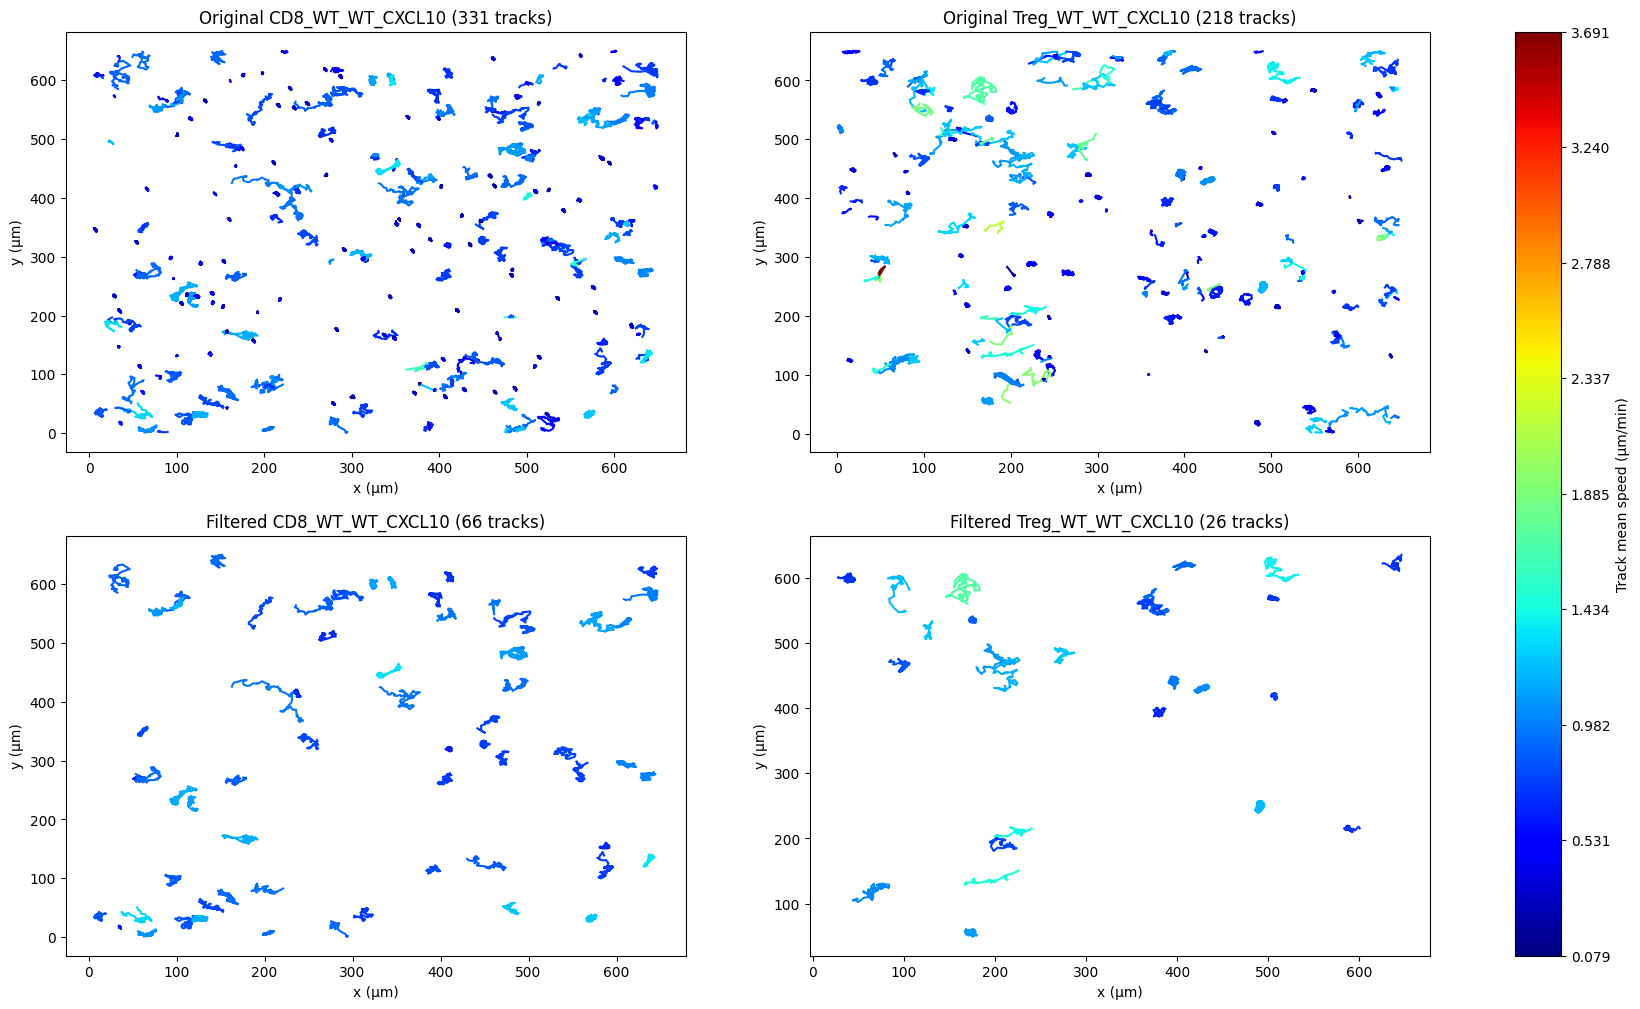

In [40]:
#Run this function to preview some filtered analyzed data
excel_dirname = fr"{exp}\{experiment.value}\{condition.value}\{timer.value}\Tracks\excel_tracks"
cmap = mpl.colormaps['jet']

fig, ax = plt.subplots(2,fig_count) ###########################
fig.set_figheight(12)
fig.set_figwidth(22)
col=0
for file in os.listdir(excel_dirname):
    if os.path.isdir(os.path.join(excel_dirname, file)):
        continue
    path = os.path.join(excel_dirname, file)
    tracks, names = traj_analysis.filter_traj(path, filter_values=params)
    og_tracks, og_names = traj_analysis.get_traj(path)
    ids = np.unique(tracks.index.get_level_values(0))
    og_ids = np.unique(og_tracks.index.get_level_values(0))
    for id in ids:
        track = tracks.loc[id]
        track_velocity = np.abs(np.diff(np.linalg.norm(track.iloc[:,slice(1, None, 1)], axis=1), axis=0))/timelapse.value
        mean_velocity = np.nanmean(track_velocity, axis=0)/limits[2][1]
        ax[1,col].plot(np.asarray(track[['x']]), np.asarray(track[['y']]), color=cmap(mean_velocity))
        ax[1,col].set_xlabel('x (μm)')
        ax[1,col].set_ylabel('y (μm)')
        ax[1,col].set_title(f'Filtered {names} ({len(ids)} tracks)')
    for og_id in og_ids:
        og_track = og_tracks.loc[og_id]
        track_velocity = np.abs(np.diff(np.linalg.norm(og_track.iloc[:,slice(1, None, 1)], axis=1), axis=0))/timelapse.value
        mean_velocity = np.nanmean(track_velocity, axis=0)/limits[2][1]
        ax[0,col].plot(np.asarray(og_track[['x']]), np.asarray(og_track[['y']]), color=cmap(mean_velocity))
        ax[0,col].set_xlabel('x (μm)')
        ax[0,col].set_ylabel('y (μm)')
        ax[0,col].set_title(f'Original {og_names} ({len(og_ids)} tracks)')
    col+=1

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(limits[2][0], limits[2][1]))
plt.colorbar(sm, ax=ax, ticks=np.linspace(limits[2][0], limits[2][1], 9), label=f"Track mean speed (μm/{timelapse_units.value})")
plt.show()

### Analyze the original tracks

Run the following cell to perform all abailable analysis to the converted tracks. Modify some of the parameters if needed.

Current available parameters are speed (mean, median, std, min, max), msd (mean msd, diffusion coefficients), acf (mean autocorrelation function), directionality, tortuosity, total turning angle and spatial coverage.

In [41]:
excel_dirname = fr"{exp}\{experiment.value}\{condition.value}\{timer.value}\Tracks\excel_tracks"
excel_savedir = fr"{exp}\{experiment.value}\{condition.value}\{timer.value}\Tracks\excel_tracks\Results"
if not os.path.exists(excel_savedir):
    os.makedirs(excel_savedir)

for file in os.listdir(excel_dirname):
    if os.path.isdir(os.path.join(excel_dirname, file)):
        continue
    path = os.path.join(excel_dirname, file)

    tracks, names = traj_analysis.crop_traj(path, filter_tracks=filter_tracks.value, filter_values=params)

    v = traj_analysis.velocity(tracks, names, timelapse_units.value, excel_savedir)
    msd = traj_analysis.get_msd(tracks, names, timelapse_units.value, excel_savedir)
    acf = traj_analysis.get_acf(tracks, names, timelapse_units.value, excel_savedir)
    dt = traj_analysis.directionality_tortuosity(tracks, names, timelapse_units.value, excel_savedir)
    ta = traj_analysis.turning_angle(tracks, names, timelapse_units.value, excel_savedir)
    sc = traj_analysis.spatial_coverage(tracks, names, timelapse_units.value, excel_savedir)
    #pdf = traj_analysis.PDF_dR(tracks, names, timelapse_units.value, calculation_tlag=6, savedir=excel_savedir)

c:\Users\pcanaleta\Documents\GitHub\tanalysis\tanalysis\traj_analysis.py:266: RuntimeWarning: Mean of empty slice
  msd = np.nanmean(msd_sum)
c:\Users\pcanaleta\Documents\GitHub\tanalysis\tanalysis\traj_analysis.py:465: RuntimeWarning: Mean of empty slice
  acf = np.nanmean(np.sum(dxyz[tlag:]*dxyz[:-tlag], axis=1))
c:\Users\pcanaleta\Documents\GitHub\tanalysis\tanalysis\traj_analysis.py:266: RuntimeWarning: Mean of empty slice
  msd = np.nanmean(msd_sum)
c:\Users\pcanaleta\Documents\GitHub\tanalysis\tanalysis\traj_analysis.py:465: RuntimeWarning: Mean of empty slice
  acf = np.nanmean(np.sum(dxyz[tlag:]*dxyz[:-tlag], axis=1))


### Parameter representation

This section will guide the user trough different proposed representations of the performed analysis. The different subsections will correspond to the different calculated parameters.

All different conditions will be represented in the same graph so they can be compared.

#### Velocity

 d_value (Mean speed): 0.24050480654689224 
 d_value (Median speed): 0.3315319884642338 
 d_value (Std speed): 0.03801776665624675 
 d_value (Max speed): 0.17263500667076548 
 d_value (Min speed): -0.12771983106251947


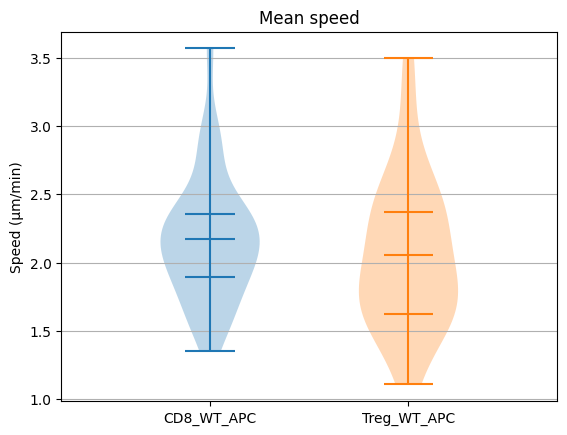

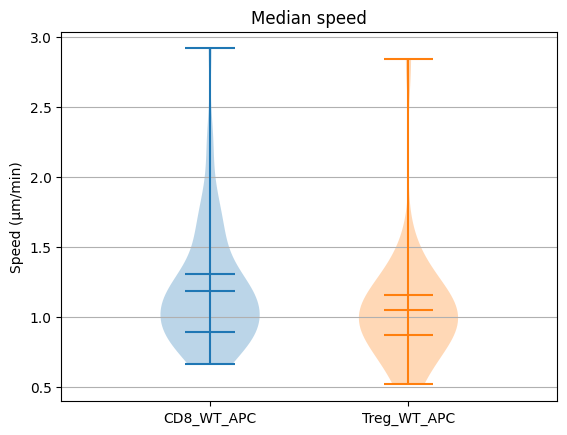

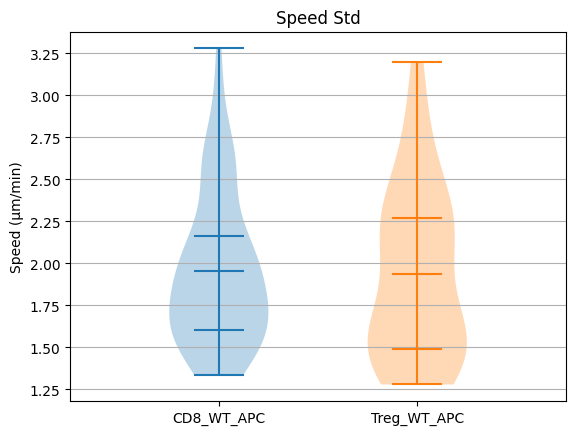

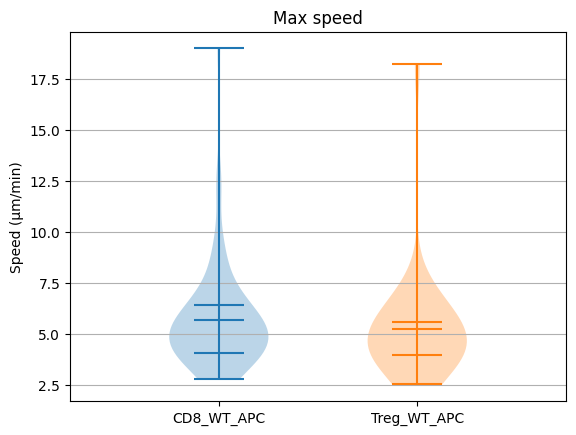

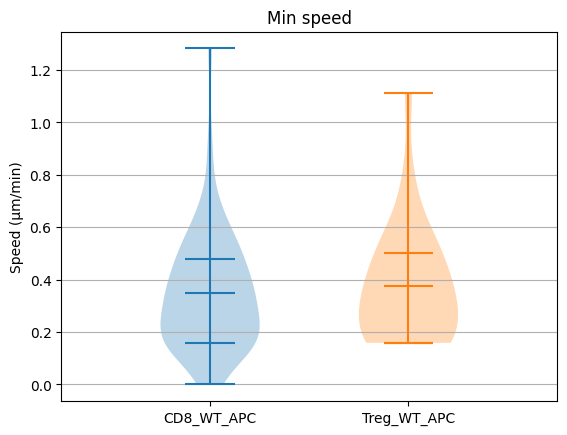

In [48]:
# Speed representation
results_dirname = fr"{exp}\{experiment.value}\{condition.value}\{timer.value}\Tracks\excel_tracks\Results"
results_savedir = fr"{exp}\{experiment.value}\{condition.value}\{timer.value}\Tracks\excel_tracks\Results\Figures"
if not os.path.exists(results_savedir):
    os.makedirs(results_savedir)

file_list=[]
fig1, ax1 = plt.subplots()
fig2, ax2 = plt.subplots()
fig3, ax3 = plt.subplots()
fig4, ax4 = plt.subplots()
fig5, ax5 = plt.subplots()
pos = [1]
labels=[]
titles = ['Mean speed', 'Median speed', 'Speed Std', 'Max speed', 'Min speed']
mean_speed = []
median_speed = []
std_speed = []
max_speed = []
min_speed = []
for file in os.listdir(results_dirname):
    if 'velocity' in file:
        file_name = file.replace(os.path.splitext(file)[-1],'').replace('_velocity','')
        path = os.path.join(results_dirname, file)
        df_params = pd.read_excel(path, 'speed_params').to_numpy()

        column = 1
        mean_speed.append(df_params[:,column])
        ax1.violinplot(df_params[:,column], positions=pos, showextrema=True, showmeans=True, quantiles=[0.25,0.75])
        median_speed.append(df_params[:,column+4])
        ax2.violinplot(df_params[:,column+4], positions=pos, showextrema=True, showmeans=True, quantiles=[0.25,0.75])
        std_speed.append(df_params[:,column+4*2])
        ax3.violinplot(df_params[:,column+4*2], positions=pos, showextrema=True, showmeans=True, quantiles=[0.25,0.75])
        max_speed.append(df_params[:,column+4*3])
        ax4.violinplot(df_params[:,column+4*3], positions=pos, showextrema=True, showmeans=True, quantiles=[0.25,0.75])
        min_speed.append(df_params[:,column+4*4])
        ax5.violinplot(df_params[:,column+4*4], positions=pos, showextrema=True, showmeans=True, quantiles=[0.25,0.75])
        labels.append(file_name)
        pos[0]+=1
    
    for ax, title in zip([ax1,ax2,ax3,ax4,ax5], titles):
        ax.set_xticks(np.arange(1, len(labels) + 1), labels=labels)
        ax.set_xlim(0.25, len(labels) + 0.75)
        ax.set_ylabel(f'Speed (μm/{timelapse_units.value})')
        ax.grid(True, axis='y')
        ax.set_title(title)
d_mean_speed = traj_analysis.cohen_d(mean_speed[0], mean_speed[1])
d_median_speed = traj_analysis.cohen_d(median_speed[0], median_speed[1])
d_std_speed = traj_analysis.cohen_d(std_speed[0], std_speed[1])
d_max_speed = traj_analysis.cohen_d(max_speed[0], max_speed[1])
d_min_speed = traj_analysis.cohen_d(min_speed[0], min_speed[1])
print(f' d_value (Mean speed): {d_mean_speed}','\n',
      f'd_value (Median speed): {d_median_speed}','\n',
      f'd_value (Std speed): {d_std_speed}','\n',
      f'd_value (Max speed): {d_max_speed}','\n',
      f'd_value (Min speed): {d_min_speed}')
plt.show()

#### Directionality and tortuosity

 d_value (Directionality): -0.1616302616492444 
 d_value (Median speed): -0.13846455581952552


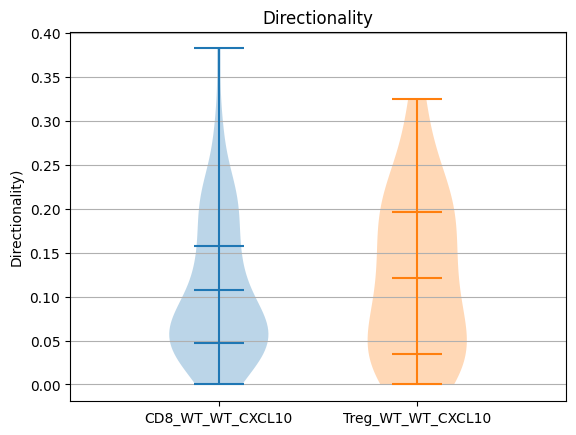

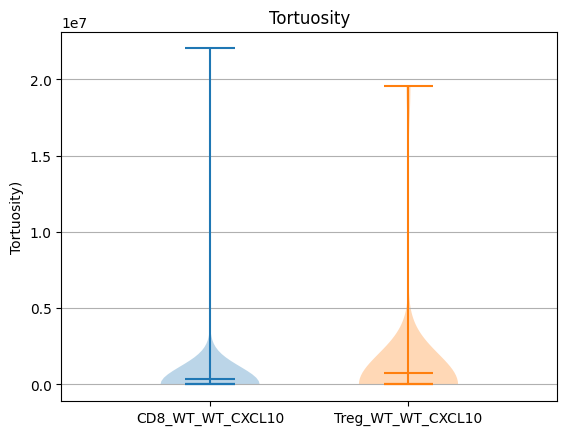

In [43]:
# Directionality and tortuosity representation
results_dirname = fr"{exp}\{experiment.value}\{condition.value}\{timer.value}\Tracks\excel_tracks\Results"
results_savedir = fr"{exp}\{experiment.value}\{condition.value}\{timer.value}\Tracks\excel_tracks\Results\Figures"
if not os.path.exists(results_savedir):
    os.makedirs(results_savedir)

file_list=[]
fig1, ax1 = plt.subplots()
fig2, ax2 = plt.subplots()
pos = [1]
labels=[]
direct = []
tort = []
titles = ['Directionality', 'Tortuosity']
for file in os.listdir(results_dirname):
    if 'directionality_tortuosity' in file:
        file_name = file.replace(os.path.splitext(file)[-1],'').replace('_directionality_tortuosity','')
        path = os.path.join(results_dirname, file)
        df_direct_tortuos = pd.read_excel(path).to_numpy()
        directionality = df_direct_tortuos[:,1]
        tortuosity = df_direct_tortuos[:,2]
        direct.append(directionality)
        tort.append(tortuosity)
        ax1.violinplot(directionality, positions=pos, showextrema=True, showmeans=True, quantiles=[0.25,0.75])
        ax2.violinplot(tortuosity, positions=pos, showextrema=True, showmeans=True, quantiles=[0.25,0.75])
        labels.append(file_name)
        pos[0]+=1
    for ax, title in zip([ax1,ax2], titles):
        ax.set_xticks(np.arange(1, len(labels) + 1), labels=labels)
        ax.set_xlim(0.25, len(labels) + 0.75)
        ax.set_ylabel(f'{title})')
        ax.grid(True, axis='y')
        ax.set_title(title)
d_direct = traj_analysis.cohen_d(direct[0], direct[1])
d_tort = traj_analysis.cohen_d(tort[0], tort[1])
print(f' d_value (Directionality): {d_direct}','\n',
      f'd_value (Median speed): {d_tort}')
plt.show()

#### Total turning angle

 d_value (Total turning angle): 0.4681170600469655 
 d_value (Persistence): 0.19890054459600912


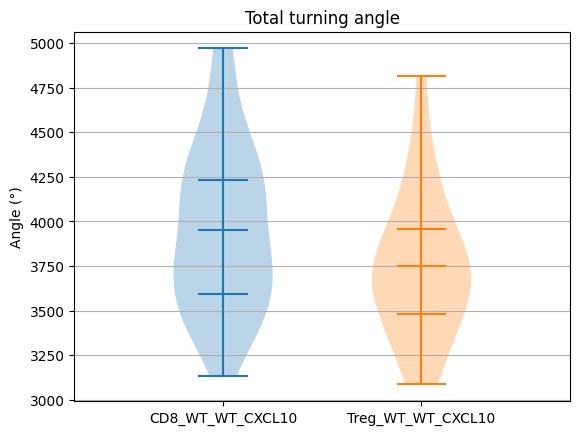

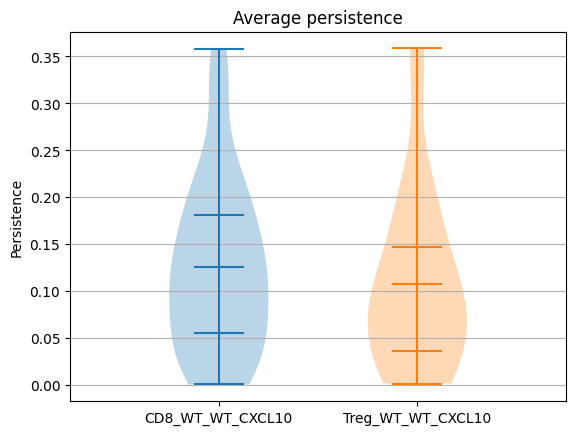

In [45]:
# Total turning angle representation
results_dirname = fr"{exp}\{experiment.value}\{condition.value}\{timer.value}\Tracks\excel_tracks\Results"
results_savedir = fr"{exp}\{experiment.value}\{condition.value}\{timer.value}\Tracks\excel_tracks\Results\Figures"
if not os.path.exists(results_savedir):
    os.makedirs(results_savedir)

file_list=[]
fig1, ax1 = plt.subplots()
fig2, ax2 = plt.subplots()
pos = [1]
labels=[]
titles = ['Total turning angle', 'Average persistence']
tta = []
persist = []
for file in os.listdir(results_dirname):
    if 'turning_angle' in file:
        file_name = file.replace(os.path.splitext(file)[-1],'').replace('_turning_angle','')
        path = os.path.join(results_dirname, file)
        df_tta = pd.read_excel(path).to_numpy()
        tta.append(df_tta[:,1])
        ax1.violinplot(df_tta[:,1], positions=pos, showextrema=True, showmeans=True, quantiles=[0.25,0.75])
        persist.append(df_tta[:,2])
        ax2.violinplot(df_tta[:,2], positions=pos, showextrema=True, showmeans=True, quantiles=[0.25,0.75])
        labels.append(file_name)
        pos[0]+=1
    
    ax1.set_xticks(np.arange(1, len(labels) + 1), labels=labels)
    ax1.set_xlim(0.25, len(labels) + 0.75)
    ax1.set_ylabel(f'Angle (°)')
    ax1.grid(True, axis='y')
    ax1.set_title(titles[0])
    ax2.set_xticks(np.arange(1, len(labels) + 1), labels=labels)
    ax2.set_xlim(0.25, len(labels) + 0.75)
    ax2.set_ylabel(f'Persistence')
    ax2.grid(True, axis='y')
    ax2.set_title(titles[1])
d_tta = traj_analysis.cohen_d(tta[0], tta[1])
d_persist = traj_analysis.cohen_d(persist[0], persist[1])
print(f' d_value (Total turning angle): {d_tta}','\n',
      f'd_value (Persistence): {d_persist}')
plt.show()

#### Spatial coverage

 d_value (Total turning angle): -0.33343304105532456


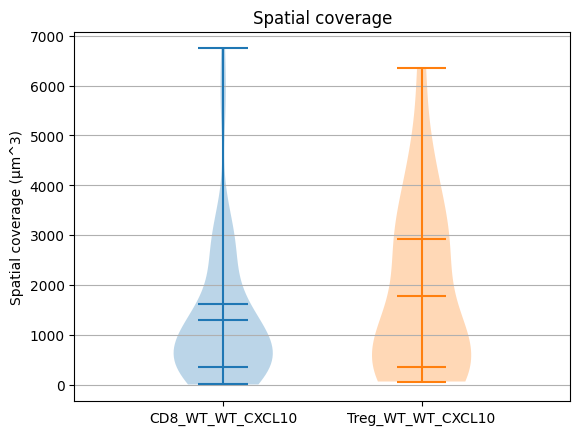

In [46]:
# Spatial coverage representation
results_dirname = fr"{exp}\{experiment.value}\{condition.value}\{timer.value}\Tracks\excel_tracks\Results"
results_savedir = fr"{exp}\{experiment.value}\{condition.value}\{timer.value}\Tracks\excel_tracks\Results\Figures"
if not os.path.exists(results_savedir):
    os.makedirs(results_savedir)

file_list=[]
fig1, ax1 = plt.subplots()
pos = [1]
labels=[]
titles = ['Spatial coverage']
spcv = []
for file in os.listdir(results_dirname):
    if 'spatial_coverage' in file:
        file_name = file.replace(os.path.splitext(file)[-1],'').replace('_spatial_coverage','')
        path = os.path.join(results_dirname, file)
        df_spcv = pd.read_excel(path).to_numpy()
        spcv.append(df_spcv[:,1])
        ax1.violinplot(df_spcv[:,1], positions=pos, showextrema=True, showmeans=True, quantiles=[0.25,0.75])
        labels.append(file_name)
        pos[0]+=1
    
    ax1.set_xticks(np.arange(1, len(labels) + 1), labels=labels)
    ax1.set_xlim(0.25, len(labels) + 0.75)
    ax1.set_ylabel(f'Spatial coverage (μm^3)')
    ax1.grid(True, axis='y')
    ax1.set_title(titles[0])
d_spcv = traj_analysis.cohen_d(spcv[0], spcv[1])
print(f' d_value (Total turning angle): {d_spcv}')
plt.show()

#### Mean Square Displacement

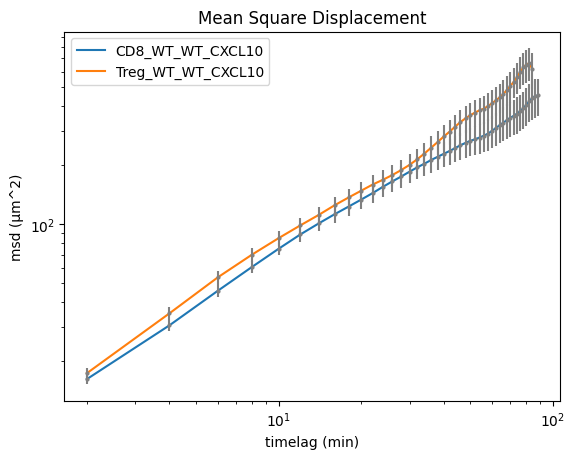

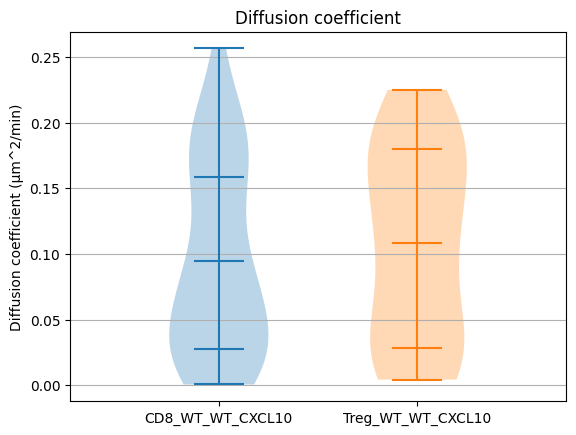

In [47]:
# Mean squared displacement representation
results_dirname = fr"{exp}\{experiment.value}\{condition.value}\{timer.value}\Tracks\excel_tracks\Results"
results_savedir = fr"{exp}\{experiment.value}\{condition.value}\{timer.value}\Tracks\excel_tracks\Results\Figures"
if not os.path.exists(results_savedir):
    os.makedirs(results_savedir)

file_list=[]
fig1, ax1 = plt.subplots()
fig2, ax2 = plt.subplots()
pos = [1]
labels=[]
titles = ['Mean Square Displacement', 'Diffusion coefficient']
for file in os.listdir(results_dirname):
    if 'msd' in file:
        file_name = file.replace(os.path.splitext(file)[-1],'').replace('_msd','')
        path = os.path.join(results_dirname, file)
        df_msd = pd.read_excel(path, sheet_name='mean_msd').to_numpy()
        df_dc = pd.read_excel(path, sheet_name='diff_coef').dropna(axis=1).to_numpy()

        ax1.plot(df_msd[:,0], df_msd[:,1], label=file_name)
        ax1.errorbar(df_msd[:,0], df_msd[:,1], df_msd[:,2], fmt='o', markersize=2, color='gray')
        ax2.violinplot(df_dc[:,1:].T.astype(float), positions=pos, showextrema=True, showmeans=True, quantiles=[0.25,0.75])
        labels.append(file_name)
        pos[0]+=1
    
ax1.set_title(titles[0])
ax1.legend()
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel(f'timelag ({timelapse_units.value})')
ax1.set_ylabel('msd (μm^2)')

ax2.set_xticks(np.arange(1, len(labels) + 1), labels=labels)
ax2.set_xlim(0.25, len(labels) + 0.75)
ax2.set_ylabel(f'Diffusion coefficient (μm^2/min)')
ax2.grid(True, axis='y')
ax2.set_title(titles[1])
plt.show()

#### Autocorrelation Function

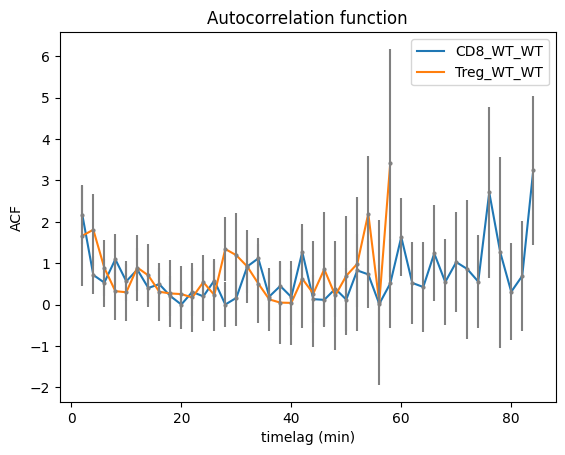

In [38]:
# Autocorrelation function representation
results_dirname = fr"{exp}\{experiment.value}\{condition.value}\{timer.value}\Tracks\excel_tracks\Results"
results_savedir = fr"{exp}\{experiment.value}\{condition.value}\{timer.value}\Tracks\excel_tracks\Results\Figures"
if not os.path.exists(results_savedir):
    os.makedirs(results_savedir)

file_list=[]
fig1, ax1 = plt.subplots()
pos = [1]
labels=[]
titles = ['Autocorrelation function']
for file in os.listdir(results_dirname):
    if 'acf' in file:
        file_name = file.replace(os.path.splitext(file)[-1],'').replace('_acf','')
        path = os.path.join(results_dirname, file)
        df_acf = pd.read_excel(path, sheet_name='mean_acf').to_numpy()

        ax1.plot(df_acf[:,0], abs(df_acf[:,1]), label=file_name)
        ax1.errorbar(df_acf[:,0], abs(df_acf[:,1]), df_acf[:,2], fmt='o', markersize=2, color='gray')
        labels.append(file_name)
        pos[0]+=1
    
ax1.set_title(titles[0])
ax1.legend()
ax1.set_xlabel(f'timelag ({timelapse_units.value})')
ax1.set_ylabel('ACF')
plt.show()

## Modelization

### Modelizing Anisotropic Persistent Random Walk

Run the following cell to fit an APRW model to the MSD of each track and simulate some trajectories using the parameters found in the fitting.

In [ ]:
savedir = fr"{exp}\{experiment.value}\{condition.value}\{timer.value}\Tracks\excel_tracks\APRW"
if not os.path.exists(savedir):
    os.makedirs(savedir)

for file in os.listdir(excel_dirname):
    if not os.path.isdir(os.path.join(excel_dirname, file)):
        tracks, names = traj_analysis.crop_traj(os.path.join(excel_dirname, file), filter_tracks=filter_tracks.value, filter_values=params)

        sim_params = traj_analysis.fit_APRW(tracks, names, savedir)
        traj_analysis.sim_APRW(sim_params, tracks, names, Nmax=37, repeats=10, subsamples=50, savedir=savedir)

In [ ]:
#Run this cell to preview some filtered vs simulated origin centered tracks
APRW_dirname = fr"{exp}\{experiment.value}\{condition.value}\{timer.value}\Tracks\excel_tracks\APRW\Simulations"

APRW_tracks, APRW_names = traj_analysis.crop_traj(APRW_dirname, False, params)
tracks, names = traj_analysis.crop_traj(excel_dirname, filter_tracks=filter_tracks.value, filter_values=params)

cmap = mpl.colormaps['jet']
fig, ax = plt.subplots(2,len(tracks))
fig.set_figheight(12)
fig.set_figwidth(22)
col=0
name=0
for file in APRW_tracks:
    for track in file:
        track_velocity = np.linalg.norm(np.diff(np.asarray(track)[:,2:], axis=0),axis=-1)/(np.diff(np.asarray(track)[:,1], axis=0))
        mean_velocity = np.mean(track_velocity, axis=-1)/limits[2][1]
        ax[1,col].plot(np.asarray(track)[:,2], np.asarray(track)[:,3], color=cmap(mean_velocity))
        ax[1,col].set_xlabel('x (μm)')
        ax[1,col].set_ylabel('y (μm)')
        ax[1,col].set_title(f'Simulated {APRW_names[name]} ({len(file)} tracks)'.replace('_sim_tracks',''))
    col+=1
    name+=1

col=0
name=0
for og_file in tracks:
    og_ids = np.unique(og_file[:,0], return_index=False)
    for og_track in og_file:
        og_track = og_track-og_track[0]
        track_velocity = np.linalg.norm(np.diff(np.asarray(og_track)[:,2:], axis=0),axis=-1)/(np.diff(np.asarray(og_track)[:,1], axis=0))
        mean_velocity = np.mean(track_velocity, axis=-1)/limits[2][1]
        ax[0,col].plot(np.asarray(og_track)[:,2], np.asarray(og_track)[:,3], color=cmap(mean_velocity))
        ax[0,col].set_xlabel('x (μm)')
        ax[0,col].set_ylabel('y (μm)')
        ax[0,col].set_title(f'Original {names[name]} ({len(og_file)} tracks)')
    col+=1
    name+=1

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(limits[2][0], limits[2][1]))
plt.colorbar(sm, ax=ax, ticks=np.linspace(limits[2][0], limits[2][1], 9), label=f"Track mean speed (μm/{timelapse_units.value})")
plt.show()

In [ ]:
excel_APRW_dirname = fr"{exp}\{experiment.value}\{condition.value}\{timer.value}\Tracks\excel_tracks\APRW\Simulations"
excel_APRW_savedir = fr"{exp}\{experiment.value}\{condition.value}\{timer.value}\Tracks\excel_tracks\APRW\Simulations\Results"
if not os.path.exists(excel_APRW_savedir):
    os.makedirs(excel_APRW_savedir)

for file in os.listdir(excel_APRW_dirname):
    if os.path.isdir(os.path.join(excel_APRW_dirname, file)):
        continue
    path = os.path.join(excel_APRW_dirname, file)

    APRW_tracks, APRW_names = traj_analysis.crop_traj(path, filter_tracks=False, filter_values=params)

    v_APRW = traj_analysis.velocity(APRW_tracks, APRW_names, timelapse_units.value, excel_APRW_savedir)
    msd_APRW = traj_analysis.get_msd(APRW_tracks, APRW_names, timelapse_units.value, excel_APRW_savedir)
    acf_APRW = traj_analysis.get_acf(APRW_tracks, APRW_names, timelapse_units.value, excel_APRW_savedir)
    dt_APRW = traj_analysis.directionality_tortuosity(APRW_tracks, APRW_names, timelapse_units.value, excel_APRW_savedir)
    ta_APRW = traj_analysis.turning_angle(APRW_tracks, APRW_names, timelapse_units.value, excel_APRW_savedir)
    sc_APRW = traj_analysis.spatial_coverage(APRW_tracks, APRW_names, timelapse_units.value, excel_APRW_savedir)

In [ ]:
# Mean squared displacement representation
results_dirname = fr"{exp}\{experiment.value}\{condition.value}\{timer.value}\Tracks\excel_tracks\Results"
results_APRW_dirname = fr"{exp}\{experiment.value}\{condition.value}\{timer.value}\Tracks\excel_tracks\APRW\Simulations\Results"
results_savedir = fr"{exp}\{experiment.value}\{condition.value}\{timer.value}\Tracks\excel_tracks\Results\Figures"
if not os.path.exists(results_savedir):
    os.makedirs(results_savedir)

file_list=[]
fig1, ax1 = plt.subplots()
fig2, ax2 = plt.subplots()
pos = [1]
labels=[]
titles = ['Mean Square Displacement', 'Diffusion coefficient']
for file in os.listdir(results_dirname):
    if 'msd' in file:
        file_name = file.replace(os.path.splitext(file)[-1],'').replace('_msd','')
        path = os.path.join(results_dirname, file)
        df_msd = pd.read_excel(path, sheet_name='mean_msd').to_numpy()
        df_dc = pd.read_excel(path, sheet_name='diff_coef').to_numpy()

        ax1.plot(df_msd[:,0], df_msd[:,1], label=file_name)
        max_msd_len = len(df_msd)
        ax1.errorbar(df_msd[:,0], df_msd[:,1], df_msd[:,2], fmt='o', markersize=2, color='gray')
        ax2.violinplot(df_dc[:,1], positions=pos, showextrema=True, showmeans=True, quantiles=[0.25,0.75])
        labels.append(file_name)
        pos[0]+=1
for APRW_file in os.listdir(results_APRW_dirname):
    if 'msd' in APRW_file:
        APRW_file_name = APRW_file.replace(os.path.splitext(APRW_file)[-1],'').replace('_msd','')
        path = os.path.join(results_APRW_dirname, APRW_file)
        df_msd = pd.read_excel(path, sheet_name='mean_msd').to_numpy()
        df_dc = pd.read_excel(path, sheet_name='diff_coef').to_numpy()

        ax1.plot(df_msd[:max_msd_len,0], df_msd[:max_msd_len,1], label=APRW_file_name, linestyle='dashed')
        ax1.errorbar(df_msd[:max_msd_len,0], df_msd[:max_msd_len,1], df_msd[:max_msd_len,2], fmt='o', markersize=2, color='gray')
        ax2.violinplot(df_dc[:,1], positions=pos, showextrema=True, showmeans=True, quantiles=[0.25,0.75])
        labels.append(APRW_file_name)
        pos[0]+=1
    
ax1.set_title(titles[0])
ax1.legend()
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel(f'timelag ({timelapse_units.value})')
ax1.set_ylabel('msd (μm^2)')

ax2.set_xticks(np.arange(1, len(labels) + 1), labels=labels)
ax2.set_xlim(0.25, len(labels) + 0.75)
ax2.set_ylabel(f'Diffusion coefficient (μm^2/min)')
ax2.grid(True, axis='y')
ax2.set_title(titles[1])
plt.show()